In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
import seaborn as sns
import matplotlib.pyplot as plt
import mlflow  
import mlflow.sklearn  

mlflow.set_experiment('Clustering_customer')


<Experiment: artifact_location='file:///D:/AI%20internship/mlruns/369829756350871935', creation_time=1760409401255, experiment_id='369829756350871935', last_update_time=1760409401255, lifecycle_stage='active', name='Clustering_customer', tags={}>

In [2]:
data=pd.read_csv("D:/AI internship/ai_intern/customer_segmentation.csv")
data.head()


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [3]:
data.shape

(2240, 29)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [5]:
data.dtypes

ID                       int64
Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Z_CostContact            int64
Z_Revenue                int64
Response                 int64
dtype: object

In [6]:
data.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [7]:
data.duplicated().sum()

np.int64(0)

In [8]:
data.dropna()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,3,0,0,0,0,0,0,3,11,0


In [9]:
data.isnull()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2236,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2237,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2238,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [10]:
data.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [34]:
data['Income'] = data['Income'].fillna(data['Income'].mean())

In [35]:
data['Age'] = 2025 - data['Year_Birth']

data['TotalKids'] = data['Kidhome'] + data['Teenhome']

spend_cols = ['MntWines','MntFruits','MntMeatProducts','MntFishProducts',
              'MntSweetProducts','MntGoldProds']
data['TotalSpend'] = data[spend_cols].sum(axis=1)

data['Dt_Customer'] = pd.to_datetime(data['Dt_Customer'], dayfirst=True, errors='coerce')
data['Customer_For'] = (pd.Timestamp.now() - data['Dt_Customer']).dt.days

In [36]:
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,TotalKids,TotalSpend,Customer_For
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,0,0,3,11,1,68,0,1617,4790
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,0,0,3,11,0,71,2,27,4240
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,0,0,3,11,0,60,0,776,4439
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,0,0,3,11,0,41,1,53,4266
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,0,0,3,11,0,44,1,422,4288


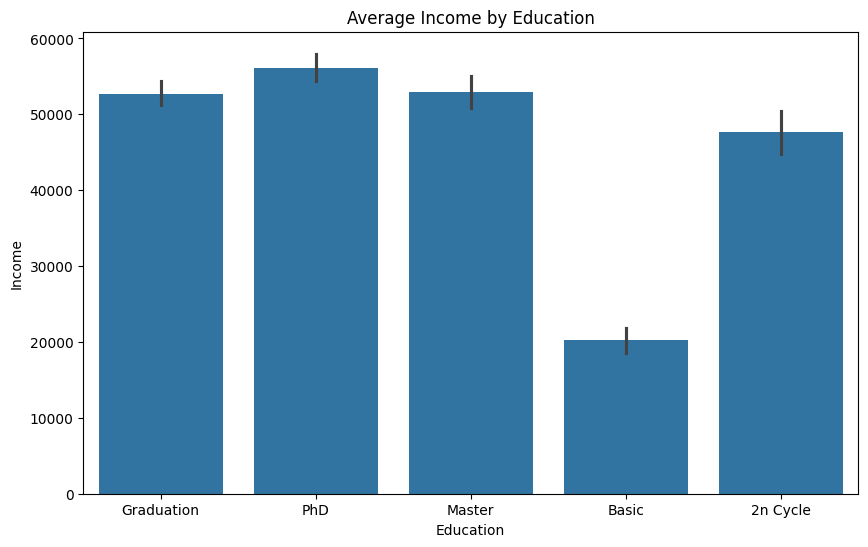

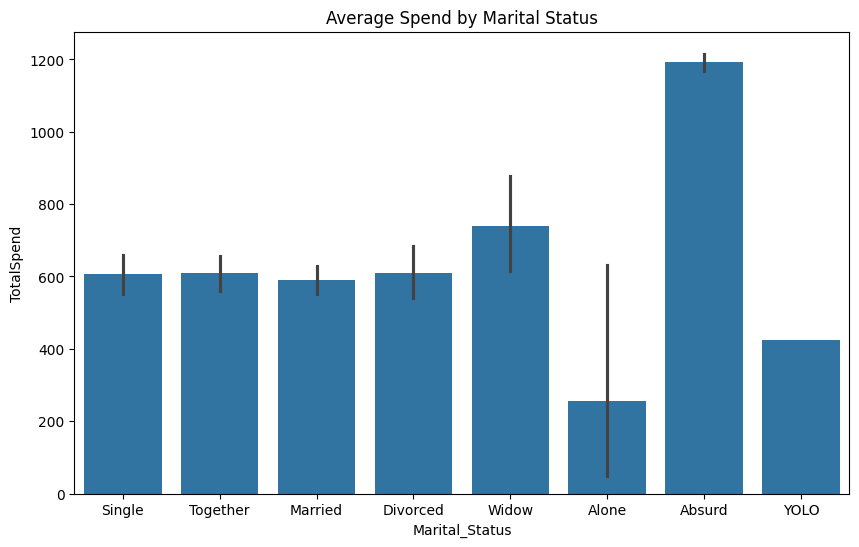

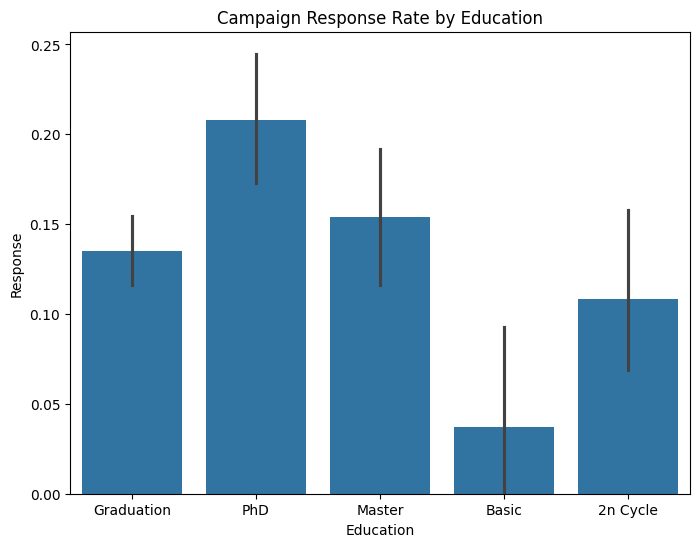

In [37]:
plt.figure(figsize=(10,6))
sns.barplot(x='Education', y='Income', data=data)
plt.title("Average Income by Education")
plt.show()

plt.figure(figsize=(10,6))
sns.barplot(x='Marital_Status', y='TotalSpend', data=data)
plt.title("Average Spend by Marital Status")
plt.show()

plt.figure(figsize=(8,6))
sns.barplot(x='Education', y='Response', data=data)
plt.title("Campaign Response Rate by Education")
plt.show()

In [38]:
from sklearn.preprocessing import StandardScaler

features_for_clustering = [
    'Age', 'Income', 'TotalSpend', 'Recency',
    'NumWebPurchases', 'NumCatalogPurchases', 
    'NumStorePurchases', 'NumWebVisitsMonth'
]

X = data[features_for_clustering]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=features_for_clustering)
X_scaled.head()

,Age,Income,TotalSpend,Recency,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
0,0.985345,0.235327,1.679417,0.307039,1.409304,2.510890,-0.550785,0.693904
1,1.235733,-0.235826,-0.961275,-0.383664,-1.110409,-0.568720,-1.166125,-0.130463
2,0.317643,0.773633,0.282673,-0.798086,1.409304,-0.226541,1.295237,-0.542647
3,-1.268149,-1.022732,-0.918094,-0.798086,-0.750450,-0.910898,-0.550785,0.281720
4,-1.017761,0.241519,-0.305254,1.550305,0.329427,0.115638,0.064556,-0.130463


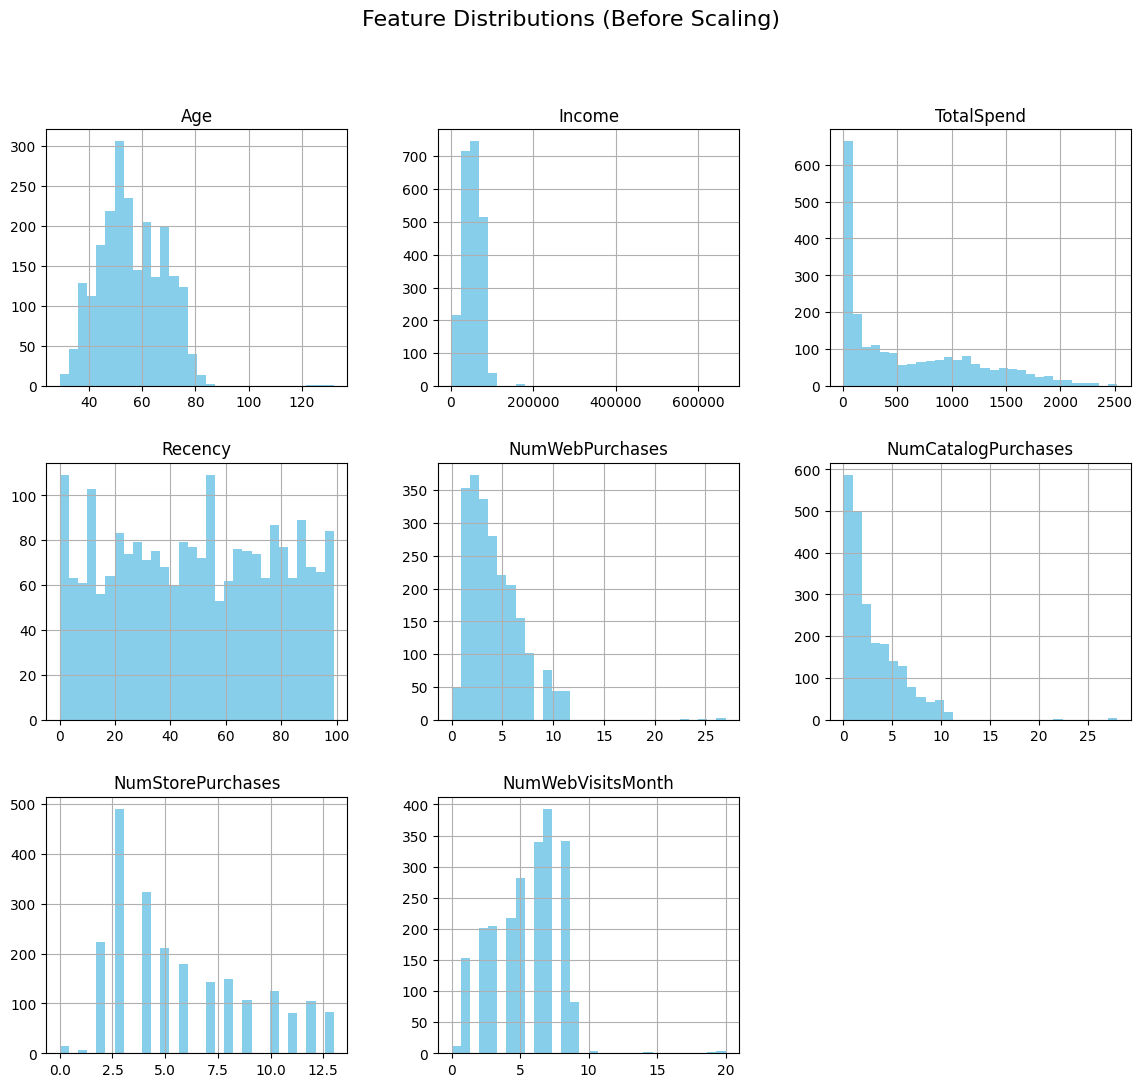

In [39]:
X.hist(figsize=(14, 12), bins=30, color='skyblue')
plt.suptitle("Feature Distributions (Before Scaling)", fontsize=16)
plt.show()

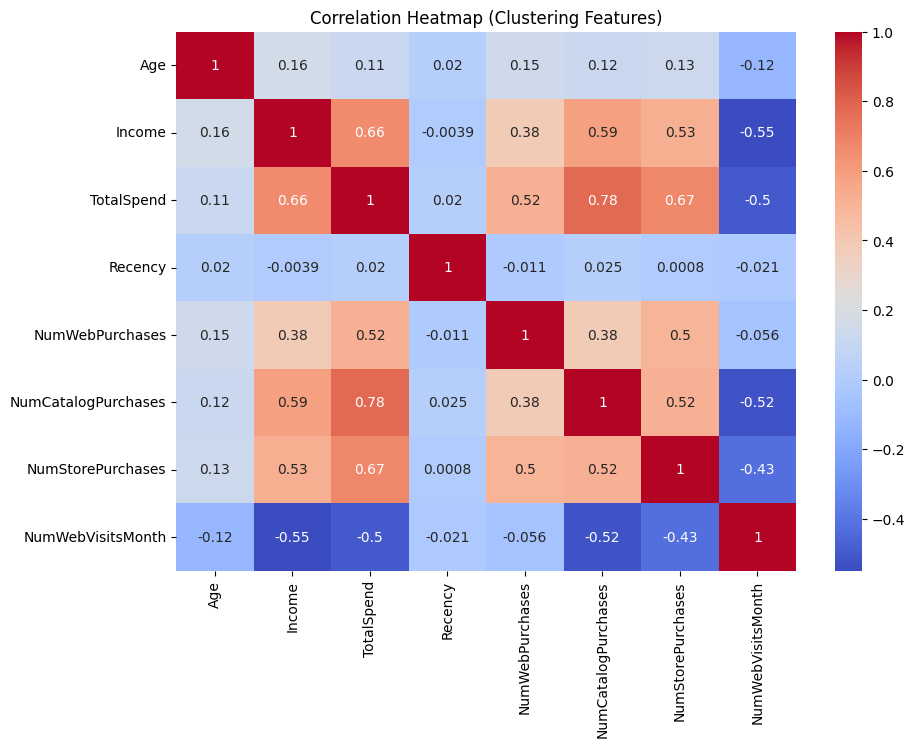

In [40]:

plt.figure(figsize=(10,7))
sns.heatmap(data[features_for_clustering].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Clustering Features)")
plt.show()

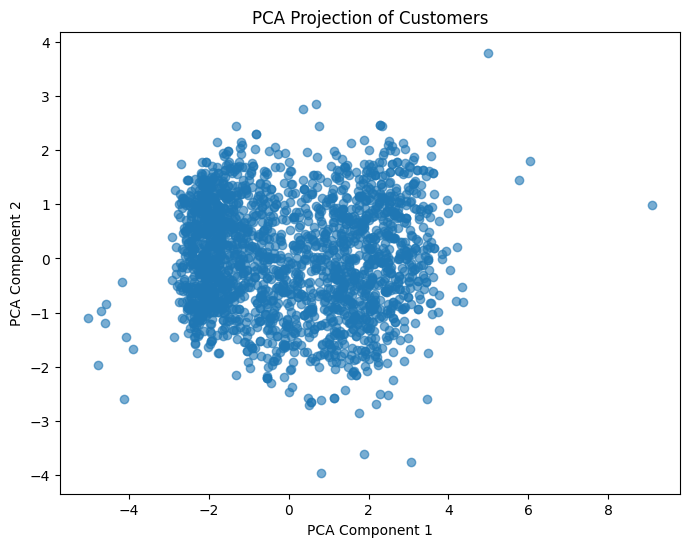

In [41]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.6)
plt.title("PCA Projection of Customers")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

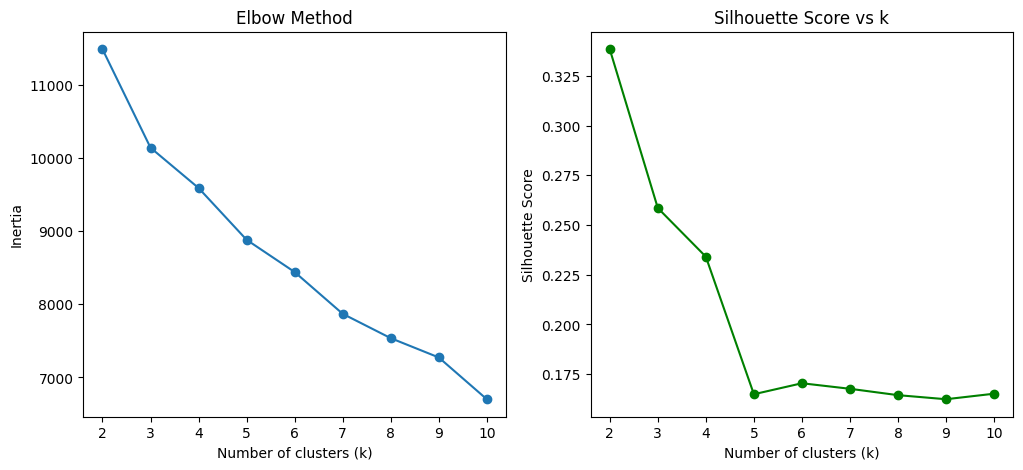

2025/10/16 07:45:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


 Best number of clusters: 2


2025/10/16 07:46:18 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


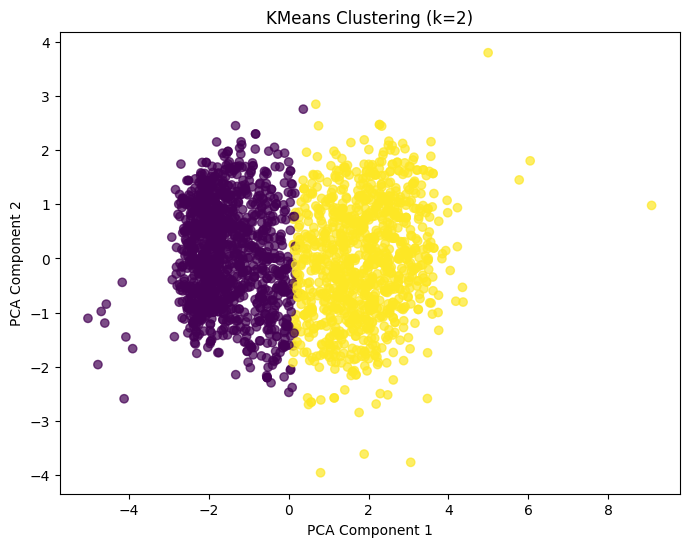

In [42]:
with mlflow.start_run(run_name="KMeans_Clustering"):
    inertia = []
    silhouette_scores = []
    K = range(2, 11)

    for k in K:
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(X_scaled)
        inertia.append(kmeans.inertia_)
        silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

    fig, ax1 = plt.subplots(1, 2, figsize=(12, 5))
    ax1[0].plot(K, inertia, marker='o')
    ax1[0].set_title("Elbow Method")
    ax1[0].set_xlabel("Number of clusters (k)")
    ax1[0].set_ylabel("Inertia")

    ax1[1].plot(K, silhouette_scores, marker='o', color='green')
    ax1[1].set_title("Silhouette Score vs k")
    ax1[1].set_xlabel("Number of clusters (k)")
    ax1[1].set_ylabel("Silhouette Score")
    plt.show()

    best_k = K[np.argmax(silhouette_scores)]
    print(f" Best number of clusters: {best_k}")

    kmeans_final = KMeans(n_clusters=best_k, random_state=42)
    kmeans_labels = kmeans_final.fit_predict(X_scaled)

    mlflow.log_param("best_k", best_k)
    mlflow.log_metric("silhouette_score", max(silhouette_scores))
    mlflow.sklearn.log_model(kmeans_final, "KMeans_Model")

    plt.figure(figsize=(8,6))
    plt.scatter(X_pca[:,0], X_pca[:,1], c=kmeans_labels, cmap='viridis', alpha=0.7)
    plt.title(f"KMeans Clustering (k={best_k})")
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.show()

    mlflow.end_run()


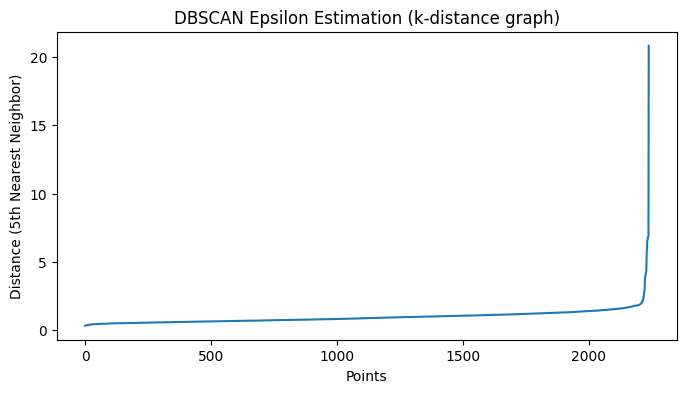

2025/10/16 07:46:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/10/16 07:46:19 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!


 DBSCAN found 1 clusters


2025/10/16 07:46:22 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


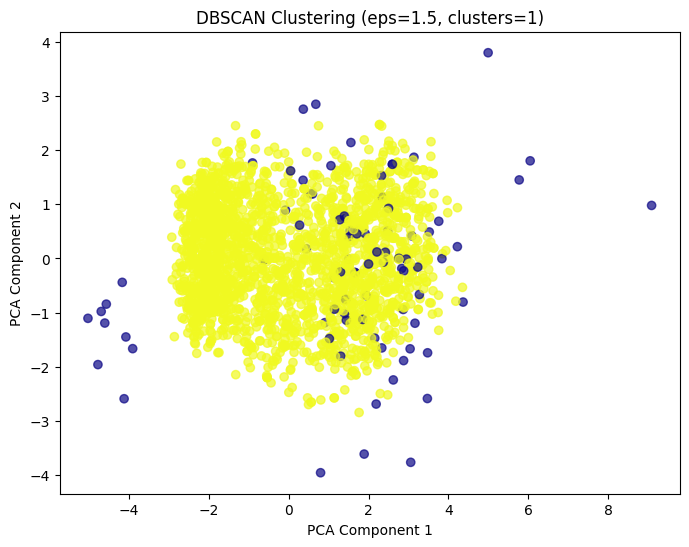

In [43]:
with mlflow.start_run(run_name="DBSCAN_Clustering"):
    neigh = NearestNeighbors(n_neighbors=5)
    nbrs = neigh.fit(X_scaled)
    distances, indices = nbrs.kneighbors(X_scaled)
    distances = np.sort(distances[:,4], axis=0)

    plt.figure(figsize=(8,4))
    plt.plot(distances)
    plt.title("DBSCAN Epsilon Estimation (k-distance graph)")
    plt.xlabel("Points")
    plt.ylabel("Distance (5th Nearest Neighbor)")
    plt.show()

    eps_value = 1.5 
    dbscan = DBSCAN(eps=eps_value, min_samples=5)
    dbscan_labels = dbscan.fit_predict(X_scaled)

    n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
    print(f" DBSCAN found {n_clusters} clusters")

    if n_clusters > 1:
        score = silhouette_score(X_scaled, dbscan_labels)
        print("Silhouette Score:", score)
        mlflow.log_metric("silhouette_score", score)

    mlflow.log_param("eps", eps_value)
    mlflow.log_param("min_samples", 5)
    mlflow.log_param("n_clusters", n_clusters)

    mlflow.sklearn.log_model(dbscan, "DBSCAN_Model")

    plt.figure(figsize=(8,6))
    plt.scatter(X_pca[:,0], X_pca[:,1], c=dbscan_labels, cmap='plasma', alpha=0.7)
    plt.title(f"DBSCAN Clustering (eps={eps_value}, clusters={n_clusters})")
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.show()

    mlflow.end_run()
